# CardioIA – Fase 2 – Parte 2: Classificador básico de texto (risco clínico)
**Autoria:** Marina Clara

**Objetivo:** dado uma frase de sintomas, prever se o paciente é **alto risco** ou **baixo risco**, simulando uma triagem clínica.

**Pipeline:** `frases (CSV)` → `TF-IDF` (texto vira números) → `modelo de classificação` → `avaliação (acurácia + análise de vieses)`.

## 1. Importações

In [1]:
import pandas as pd                      # pandas: leitura e manipulação de tabelas (DataFrame)
import numpy as np                       # numpy: operações numéricas
import matplotlib.pyplot as plt          # matplotlib: gráficos

from sklearn.model_selection import train_test_split          # divide treino/teste
from sklearn.feature_extraction.text import TfidfVectorizer   # TF-IDF: texto -> vetores
from sklearn.linear_model import LogisticRegression           # modelo 1
from sklearn.tree import DecisionTreeClassifier               # modelo 2
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

## 2. Carregando e inspecionando a base
Antes de treinar, **olhamos os dados**: quantas linhas há e se as classes estão balanceadas.
Uma base desbalanceada (ex.: 90% baixo risco) faria o modelo "acertar" só chutando a classe mais comum – isso é um **viés de dados**.

In [2]:
df = pd.read_csv("dataset_risco.csv")     # colunas: frase, situacao
print("Total de frases:", len(df))
print(df["situacao"].value_counts())       # contagem por classe (balanceamento)
df.sample(5, random_state=1)               # amostra aleatória para conferir

Total de frases: 64
situacao
alto risco     32
baixo risco    32
Name: count, dtype: int64


,frase,situacao
24,meu coração acelerou de repente e sinto dor no...,alto risco
39,estou com sono e um pouco de cansaço no fim do...,baixo risco
52,senti um leve incômodo no ombro depois de carr...,baixo risco
27,"estou com a pele pálida, suor frio e dor no peito",alto risco
44,sinto formigamento leve no pé depois de ficar ...,baixo risco


## 3. Separando treino e teste
- **Treino (75%)**: o modelo aprende.
- **Teste (25%)**: dados que ele **nunca viu**, para medir se generaliza.
- `stratify=y` mantém a mesma proporção de classes nos dois conjuntos.
- `random_state` fixa o sorteio → resultado reprodutível.

In [3]:
X = df["frase"]       # entrada: o texto
y = df["situacao"]    # saída desejada: o rótulo

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Treino:", len(X_treino), "| Teste:", len(X_teste))

Treino: 48 | Teste: 16


## 4. TF-IDF: transformando texto em números
Modelos de ML só entendem números. O **TF-IDF** dá um peso a cada palavra:
- **TF** (Term Frequency): quanto a palavra aparece **na frase**.
- **IDF** (Inverse Document Frequency): palavras **raras na base toda** valem mais; palavras comuns ("de", "e") valem menos.

`ngram_range=(1,2)` usa também pares de palavras ("dor no", "falta de"), capturando um pouco de contexto.
**Importante:** o vetorizador faz `fit` **só no treino** (para não "espiar" o teste – isso seria *data leakage*).

In [4]:
vetorizador = TfidfVectorizer(lowercase=True, ngram_range=(1, 2))
X_treino_tfidf = vetorizador.fit_transform(X_treino)   # aprende o vocabulário + transforma
X_teste_tfidf  = vetorizador.transform(X_teste)        # só transforma (usa o vocabulário do treino)
print("Formato da matriz de treino (frases x termos):", X_treino_tfidf.shape)

Formato da matriz de treino (frases x termos): (48, 432)


## 5. Treinando os modelos
Comparamos dois modelos simples:
- **Regressão Logística:** aprende um peso por termo; interpretável (dá para ver quais palavras empurram para "alto risco").
- **Árvore de Decisão:** aprende perguntas do tipo "o termo X está presente?".

In [5]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "Árvore de Decisão":  DecisionTreeClassifier(random_state=42),
}
resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_treino_tfidf, y_treino)                 # treino
    previsoes = modelo.predict(X_teste_tfidf)            # previsão no teste
    resultados[nome] = accuracy_score(y_teste, previsoes)
    print(f"\n=== {nome} === acurácia: {resultados[nome]:.2%}")
    print(classification_report(y_teste, previsoes, zero_division=0))


=== Regressão Logística === acurácia: 87.50%
              precision    recall  f1-score   support

  alto risco       1.00      0.75      0.86         8
 baixo risco       0.80      1.00      0.89         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16


=== Árvore de Decisão === acurácia: 87.50%
              precision    recall  f1-score   support

  alto risco       1.00      0.75      0.86         8
 baixo risco       0.80      1.00      0.89         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16



## 6. Matriz de confusão
Mostra **onde** o modelo erra. O erro mais grave em triagem é o **falso negativo** (paciente de alto risco classificado como baixo risco).

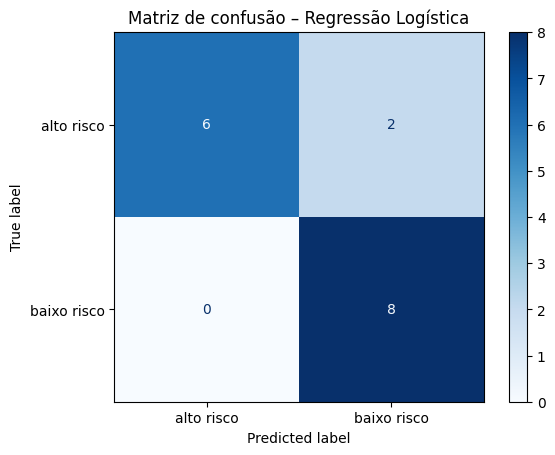

In [6]:
melhor_nome = max(resultados, key=resultados.get)
melhor = modelos[melhor_nome]
ConfusionMatrixDisplay.from_estimator(melhor, X_teste_tfidf, y_teste, cmap="Blues")
plt.title(f"Matriz de confusão – {melhor_nome}")
plt.show()

## 7. Quais palavras o modelo usa? (procurando padrões e distorções)
Na regressão logística cada termo recebe um coeficiente. O sinal é relativo à **segunda classe** em `classes_` (ordem alfabética: `alto risco` é a 1ª e `baixo risco` a 2ª). Então coeficiente **positivo** empurra para `baixo risco` e **negativo** empurra para `alto risco`. Imprimimos `classes_` para conferir.

In [7]:
lr = modelos["Regressão Logística"]
print("Classes (ordem):", lr.classes_)          # a 2ª classe é a que tem coeficiente positivo
termos = np.array(vetorizador.get_feature_names_out())
ordem = np.argsort(lr.coef_[0])
print("\nTermos que mais indicam", lr.classes_[0], ":", list(termos[ordem[:10]]))
print("Termos que mais indicam", lr.classes_[1], ":", list(termos[ordem[-10:]]))

Classes (ordem): ['alto risco' 'baixo risco']

Termos que mais indicam alto risco : ['no peito', 'peito', 'dor no', 'falta', 'falta de', 'ar', 'de ar', 'no', 'coração', 'forte']
Termos que mais indicam baixo risco : ['um leve', 'cabeça', 'passou', 'tive uma', 'um', 'depois de', 'tive', 'uma', 'depois', 'leve']


## 8. Testando frases novas de risco diferente
Aqui incluímos casos **difíceis de propósito**: negação ("**sem** dor no peito"), sintomas leves com palavra "forte", e frases fora do padrão do treino.
Se o modelo errar, isso evidencia limites reais: ele aprende **palavras**, não **significado clínico**.

In [8]:
novas = [
    "sinto dor no peito e suor frio",                      # esperado: alto risco
    "tive um leve incômodo nas costas",                    # esperado: baixo risco
    "estou com falta de ar e meu coração disparado",       # esperado: alto risco
    "vim para o check-up anual, sem dor no peito",         # esperado: baixo risco (NEGAÇÃO)
    "minha avó teve infarto, mas eu estou bem",            # esperado: baixo risco (palavra de alto risco, contexto leve)
    "sinto uma pressão forte e esquisita no meio do peito",# esperado: alto risco (vocabulário diferente)
    "tive cansaço depois de correr",                       # esperado: baixo risco
]
tabela = pd.DataFrame({"frase": novas})
for nome, modelo in modelos.items():
    tabela[nome] = modelo.predict(vetorizador.transform(novas))
pd.set_option("display.max_colwidth", 70)
tabela

,frase,Regressão Logística,Árvore de Decisão
0,sinto dor no peito e suor frio,alto risco,alto risco
1,tive um leve incômodo nas costas,baixo risco,baixo risco
2,estou com falta de ar e meu coração disparado,alto risco,alto risco
3,"vim para o check-up anual, sem dor no peito",alto risco,alto risco
4,"minha avó teve infarto, mas eu estou bem",baixo risco,baixo risco
5,sinto uma pressão forte e esquisita no meio do peito,alto risco,alto risco
6,tive cansaço depois de correr,baixo risco,baixo risco


## 9. Conclusões e governança de dados
- **Acurácia alta não é garantia:** a base é pequena (64 frases) e **simulada**; as frases de alto risco compartilham palavras-chave ("dor no peito", "falta de ar"), então o modelo pode estar só memorizando vocabulário.
- **Negação e contexto:** TF-IDF ignora a ordem e o sentido; "sem dor no peito" tende a ser lido como risco por conter "dor no peito".
- **Viés de dados:** a base reflete o vocabulário de quem escreveu as frases (linguagem padronizada). Pacientes que descrevem sintomas de outro jeito (regionalismos, linguagem coloquial, idosos, mulheres, que têm apresentações atípicas de infarto) podem ser **subestimados**.
- **Custo dos erros:** falso negativo (alto risco → baixo risco) é muito pior que falso positivo. Em uso real, ajustaríamos o limiar para priorizar *recall* da classe alto risco.
- **Próximos passos:** mais dados reais e anonimizados (LGPD), tratamento de negação, validação cruzada e revisão por profissionais de saúde.

> Protótipo acadêmico. Não substitui avaliação médica.